# Tenerife Weekly Audit + EDA (TFE)

**Project:** Climate–Mortality 
#### EDA scope for this notebook
#### Island: Tenerife
#### Dataset version used here: 2016–2025
#### Note:
 - This notebook is intentionally pinned to the 2016–2025 master dataset
   
**Saved outputs:** QA tables and key descriptive tables (CSV) under `reports/islands/tables/tenerife`.


## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ISLAND_NAME = "tenerife"
ISLAND_CODE = "tfe"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"


CWD : C:\dev\projects\climate_mortality\islands\tenerife
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\tenerife
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\tenerife
FP: C:\dev\projects\climate_mortality\data\processed\tenerife\master\master_tfe_2016_2025.parquet


## 1. Load data
Load the island master dataset and subset.


In [3]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(df,
       required=["week_start","deaths_week"],
       key=["week_start"],
       dt="week_start")

num_summary(df)


EDA core weekly tenerife
Loaded: C:\dev\projects\climate_mortality\data\processed\tenerife\master\master_tfe_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_tfe ---
shape: (523, 41)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                              float64
low_vis_confirmed_days_we

,week_start,year,island,island_code,deaths_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,tmin_c_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,tenerife,tfe,129.0,3,19.300000,23.966667,24.3,14.666667,...,54.000000,3.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,tenerife,tfe,132.0,7,19.100000,23.342857,24.1,14.828571,...,56.571429,7.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,tenerife,tfe,162.0,7,21.642857,26.042857,29.3,17.242857,...,46.571429,7.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,tenerife,tfe,153.0,7,20.100000,24.071429,25.4,16.157143,...,60.285714,7.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,tenerife,tfe,117.0,7,20.628571,24.671429,27.2,16.614286,...,65.142857,7.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
year,523.0,2020.491396,2.883003,2015.000000,2018.000000,2020.000000,2023.000000,2025.000000
deaths_week,523.0,140.554493,22.292603,92.000000,124.000000,140.000000,154.000000,214.000000
n_days,523.0,6.948375,0.320459,3.000000,7.000000,7.000000,7.000000,7.000000
temp_c_mean,523.0,22.127244,2.695216,16.985714,19.942857,21.957143,24.357143,30.971429
tmax_c_mean,523.0,26.035696,2.858954,20.400000,23.700000,25.771429,28.171429,36.942857
tmax_c_max,523.0,28.123136,3.797642,21.200000,25.300000,27.700000,30.000000,44.300000
tmin_c_mean,523.0,18.216881,2.627344,12.728571,16.085714,18.200000,20.421429,24.985714
tmin_c_min,523.0,16.683174,2.771451,10.300000,14.400000,16.600000,19.100000,23.500000
humidity_mean,523.0,61.590057,6.725524,27.714286,59.000000,62.428571,65.500000,77.714286
pressure_hpa_mean,523.0,1009.721331,2.951741,1000.542857,1007.650000,1009.307143,1011.221429,1018.814286


In [4]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
elif "tmax_anom_mean" in df.columns:
    print("tmax_anom_mean already present.")
else:
    print("Missing base column tmax_c_mean.")

corr_tmax_anom = df[["deaths_week", "tmax_anom_mean"]].dropna().corr().iloc[0, 1]
print("Corr Tmax_anom:",corr_tmax_anom)

Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Corr Tmax_anom: 0.054059014340508346


In [5]:
# --- derive only missing anomaly columns actually needed ---

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")


Created excess_deaths from deaths_week using month-of-year mean.


In [7]:
# Ensure weekly datetime
df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')

# Subset to island if needed
if 'island_code' in df.columns:
    df = df.loc[df['island_code'].eq(ISLAND_CODE)].copy()

df = df.sort_values('week_start').reset_index(drop=True)
glance(df, label=f"{ISLAND_CODE}_master_weekly", n=5)

# Merge calima proxy weekly dataset (kept external to the base master)
calima_fp = ROOT / 'data' / 'processed' / ISLAND_NAME / 'calima' / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print('Calima proxy FP:', calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima['week_start'] = pd.to_datetime(calima['week_start'], errors='coerce')

    keep = [
        'week_start',
        'calima_proxy_score',
        'calima_proxy_level',
    ]
    extra_keep = [c for c in [
        'cap_dust_yellow_plus_week',
        'cap_dust_level_max_week',
        'calima_dai_flag',
    ] if c in calima.columns]

    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != 'week_start' and c in df.columns]
    if overlap:
        print('Dropping overlapping columns before merge:', overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on='week_start', how='left')
    print('Merged calima proxy columns:', [c for c in calima_keep if c != 'week_start'])
else:
    print('Calima proxy weekly dataset not found. Section 6.1 will be skipped.')

print(df.shape)



--- tfe_master_weekly ---
shape: (523, 46)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
n_days                                  int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
coverage                              float64
low_vis_confirmed_days_week           float64
low_vis_confirmed_any_week            float64
low_vis_possible_days_week            float64
low_vis_possible_any_week             float64
low_vis_any_days_week     

,week_start,year,island,island_code,deaths_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,tmin_c_mean,...,cap_coverage_week,calima_level_week,month,tmax_anom_mean,excess_deaths,calima_proxy_score,calima_proxy_level,cap_dust_yellow_plus_week,cap_dust_level_max_week,calima_dai_flag
0,2015-12-28,2015,tenerife,tfe,129.0,3,19.300000,23.966667,24.3,14.666667,...,NaN,0.0,12,0.329407,-22.133333,0.5,no_calima,NaN,NaN,0.0
1,2016-01-04,2016,tenerife,tfe,132.0,7,19.100000,23.342857,24.1,14.828571,...,NaN,0.0,1,0.381958,-36.577778,0.5,no_calima,NaN,NaN,0.0
2,2016-01-11,2016,tenerife,tfe,162.0,7,21.642857,26.042857,29.3,17.242857,...,NaN,0.0,1,3.081958,-6.577778,1.5,possible,NaN,NaN,0.0
3,2016-01-18,2016,tenerife,tfe,153.0,7,20.100000,24.071429,25.4,16.157143,...,NaN,0.0,1,1.110529,-15.577778,0.5,no_calima,NaN,NaN,0.0
4,2016-01-25,2016,tenerife,tfe,117.0,7,20.628571,24.671429,27.2,16.614286,...,NaN,0.0,1,1.710529,-51.577778,1.5,possible,NaN,NaN,0.0


Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2016_2025.parquet
Dropping overlapping columns before merge: ['calima_proxy_score', 'calima_proxy_level', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
(523, 46)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [8]:
qa = checks(df, required=['week_start','deaths_week'], key=['week_start'], dt='week_start')
display(qa)

miss = missing_table(df)
display(miss.head(25))


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1517
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_level_week,198,0.3786
calima_dai_flag,198,0.3786
cap_heat_yellow_plus_week,129,0.2467
cap_coverage_week,129,0.2467
cap_heat_level_max_week,129,0.2467
cap_dust_level_max_week,129,0.2467
cap_dust_yellow_plus_week,129,0.2467
O3,54,0.1033
NO2,54,0.1033
SO2,53,0.1013


In [9]:
# Save QA tables
save_table(qa.reset_index(), TAB_DIR, f"{ISLAND_CODE}_qa_checks.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"{ISLAND_CODE}_missing_top50.csv")

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\tfe_qa_checks.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\tfe_missing_top50.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/tfe_missing_top50.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [10]:
core_cols = [
    'deaths_week',
    'temp_c_mean','tmax_c_mean','tmin_c_mean',
    'humidity_mean','pressure_hpa_mean','wind_ms_mean',
    'PM10','PM2.5','SO2','NO2','O3',
    'cap_heat_level_max_week','cap_dust_level_max_week',
    'cap_heat_yellow_plus_week','cap_dust_yellow_plus_week',
    'cap_coverage_week','calima_dai_flag',
    'low_vis_any_week','vis_min_m_week','rh_min_pct_week'
]
desc = num_summary(df, cols=core_cols)
display(desc)


,count,mean,std,min,25%,50%,75%,max
deaths_week,523.0,140.554493,22.292603,92.000000,124.000000,140.000000,154.000000,214.000000
temp_c_mean,523.0,22.127244,2.695216,16.985714,19.942857,21.957143,24.357143,30.971429
tmax_c_mean,523.0,26.035696,2.858954,20.400000,23.700000,25.771429,28.171429,36.942857
tmin_c_mean,523.0,18.216881,2.627344,12.728571,16.085714,18.200000,20.421429,24.985714
humidity_mean,523.0,61.590057,6.725524,27.714286,59.000000,62.428571,65.500000,77.714286
pressure_hpa_mean,523.0,1009.721331,2.951741,1000.542857,1007.650000,1009.307143,1011.221429,1018.814286
wind_ms_mean,523.0,6.245554,1.515976,3.057143,5.071429,6.228571,7.357143,10.942857
PM10,523.0,49.156980,55.978399,5.735228,22.071429,33.285714,51.857143,580.142857
PM2.5,523.0,15.299599,12.339274,3.428571,8.617230,11.857143,17.121429,132.714286
SO2,470.0,7.658612,4.874991,2.000000,4.142857,6.619048,10.250000,39.571429


In [11]:
desc.to_csv(TAB_DIR / f"desc_core_{ISLAND_CODE}.csv")
print('Saved:', TAB_DIR / f"desc_core_{ISLAND_CODE}.csv")


Saved: C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\desc_core_tfe.csv


## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_weekly_deaths_timeseries.png


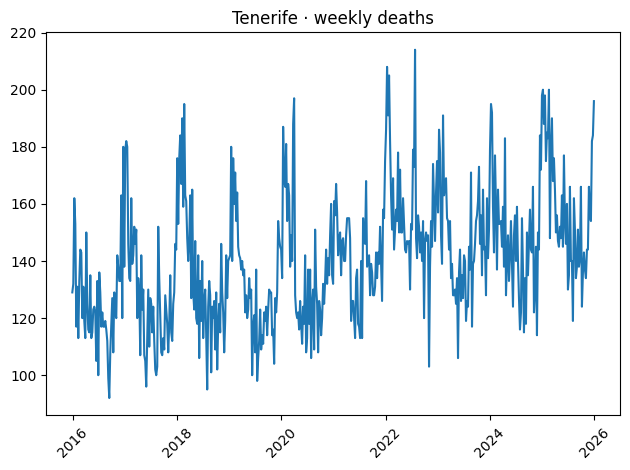

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_weekly_tmax_timeseries.png


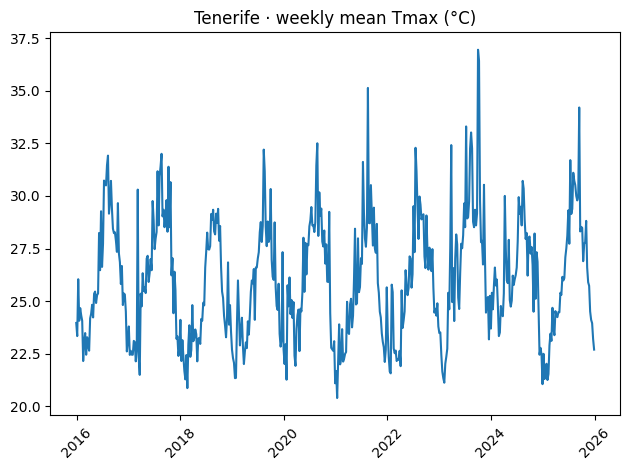

In [12]:
plt.figure()
plt.plot(df['week_start'], df['deaths_week'])
plt.title(f"{ISLAND_NAME.capitalize()} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df['week_start'], df['tmax_c_mean'])
plt.title(f"{ISLAND_NAME.capitalize()} · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_deaths_vs_absolute_tmax_scatter.png


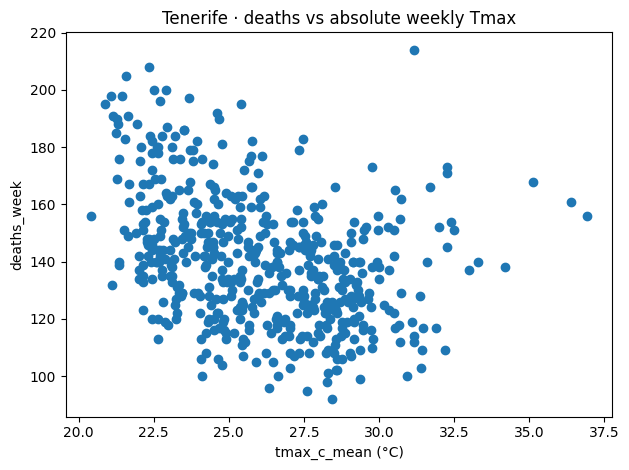

corr(deaths, tmax_c_mean): -0.363


In [13]:
plt.figure()
plt.scatter(df['tmax_c_mean'], df['deaths_week'])
plt.xlabel('tmax_c_mean (°C)')
plt.ylabel('deaths_week')
plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[['deaths_week','tmax_c_mean']].corr().iloc[0,1]
print('corr(deaths, tmax_c_mean):', round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_deaths_vs_temperature_anomaly_scatter.png


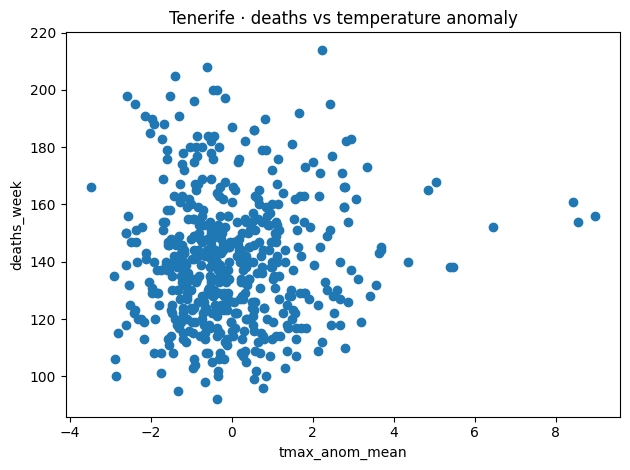

corr(deaths, tmax_anom_mean): 0.0541


In [14]:
anom_col = None
for c in ['tmax_anom_mean_week','tmax_anom_mean','tmax_anom_c_mean','tmax_anom']:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print('No anomaly column found in this master. (Skip or create anomalies upstream.)')
else:
    plt.figure()
    plt.scatter(df[anom_col], df['deaths_week'])
    plt.xlabel(anom_col)
    plt.ylabel('deaths_week')
    plt.title(f"{ISLAND_NAME.capitalize()} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[['deaths_week', anom_col]].corr().iloc[0,1]
    print(f'corr(deaths, {anom_col}):', round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [15]:
# --- official heat flags for this notebook ---
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

Official heat thresholds from tmax_c_mean -> p90=29.57, p95=30.73
heat_p95
0    496
1     27
Name: count, dtype: int64


In [16]:
tmp = df.copy()

tab_p95 = tmp.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))


,count,mean,median
heat_p95,,,
0,496,140.574597,139.5
1,27,140.185185,140.0


Δ deaths (heat_p95 vs baseline): -0.39


In [17]:
save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\heat_p95_deaths_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/heat_p95_deaths_tfe.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


float64
calima_dai_flag
0.000000    277
NaN         198
0.333333      5
0.370370      4
0.444444      4
1.500150      2
0.555556      2
0.350877      2
4.390458      2
0.517277      2
0.681849      2
0.919540      2
3.247808      2
7.794232      2
0.939920      1
0.416667      1
0.761905      1
0.796020      1
0.740741      1
0.512821      1
Name: count, dtype: int64


,missing,missing_pct
calima_proxy_score,0,0.0
calima_proxy_level,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_audit_missing_tfe.csv


,calima_proxy_level,weeks
0,no_calima,310
1,possible,138
2,intense,40
3,probable,35


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_level_counts_tfe.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_calima_proxy_level_distribution.png


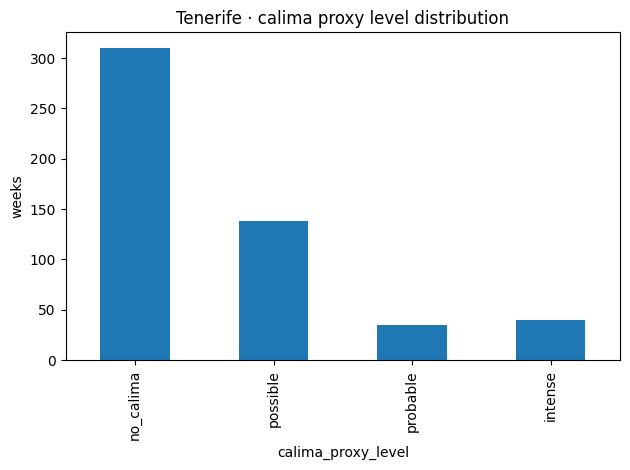

cap_dust_yellow_plus_week,0.0,1.0,NaN
calima_proxy_level,,,
intense,23,14,3
no_calima,234,1,75
possible,94,6,38
probable,20,2,13


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_vs_cap_yellow_tfe.csv
Alignment: 0.6956521739130435


calima_dai_flag,0.000000,0.333333,0.350877,0.370370,0.416667,0.444444,0.512821,0.517277,0.555556,0.641026,...,1.500150,1.538462,2.164502,2.318841,3.247808,3.864734,4.390458,7.794232,16.666667,NaN
calima_proxy_level,,,,,,,,,,,,,,,,,,,,,
intense,7,0,0,0,0,2,1,0,0,0,...,2,1,1,0,2,1,0,2,1,0
no_calima,179,1,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,2
possible,79,2,1,2,0,1,0,1,0,1,...,0,0,0,1,0,0,1,0,0,0
probable,12,2,1,1,1,1,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_vs_dai_valid_tfe.csv


In [19]:
proxy_cols = ['calima_proxy_score', 'calima_proxy_level']
have_proxy = all(c in df.columns for c in proxy_cols)

print(df["calima_dai_flag"].dtype)
print(df["calima_dai_flag"].value_counts(dropna=False).head(20))

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename('missing').to_frame()
    proxy_na['missing_pct'] = (proxy_na['missing'] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={'index': 'column'}), TAB_DIR , f"calima_proxy_audit_missing_{ISLAND_CODE}.csv", index=False)

    proxy_counts = (
        df['calima_proxy_level']
        .value_counts(dropna=False)
        .rename_axis('calima_proxy_level')
        .reset_index(name='weeks')
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df['calima_proxy_level'].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ['no_calima', 'possible', 'probable', 'intense']
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index]).dropna()

        plt.figure()
        plot_counts.plot(kind='bar')
        plt.ylabel('weeks')
        plt.title(f"{ISLAND_NAME.capitalize()} · calima proxy level distribution")
        plt.tight_layout()
        autosave_fig(FIG_DIR / f"{ISLAND_CODE}_eda01_calima_proxy_level_distribution.png")
        plt.show()

    if 'cap_dust_yellow_plus_week' in df.columns:
        cap_xtab = pd.crosstab(df['calima_proxy_level'], df['cap_dust_yellow_plus_week'], dropna=False)
        display(cap_xtab)
        save_table(cap_xtab, TAB_DIR, f"calima_proxy_vs_cap_yellow_{ISLAND_CODE}.csv", index=False)
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level"].isin(["probable", "intense"])
        
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        
        print("Alignment:",alignment)

    if 'calima_dai_flag' in df.columns:
        dai_valid = df['week_start'] <= pd.Timestamp('2022-03-31')
        dai_xtab = pd.crosstab(
            df.loc[dai_valid, 'calima_proxy_level'],
            df.loc[dai_valid, 'calima_dai_flag'],
            dropna=False
        )
        display(dai_xtab)
        save_table(dai_xtab, TAB_DIR, f"calima_proxy_vs_dai_valid_{ISLAND_CODE}.csv",index=False)
else:
    print(f"No calima proxy columns found after merge. Check the processed {ISLAND_NAME.capitalize()} calima dataset path and column names.")


In [20]:
#calima_proxi_score distribution
score_dist = (
    df["calima_proxy_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("calima_proxy_score")
    .reset_index(name="weeks")
)

score_dist["pct"] = score_dist["weeks"] / len(df) * 100
score_dist["pct"] = score_dist["pct"].round(6)

display(score_dist)

save_table(
    score_dist,
    TAB_DIR,
    f"calima_proxy_score_distribution_{ISLAND_CODE}.csv",
    index=False
)

,calima_proxy_score,weeks,pct
0,0.0,250,47.801147
1,0.5,60,11.472275
2,1.0,94,17.973231
3,1.5,44,8.413002
4,2.0,29,5.544933
5,2.5,6,1.147228
6,3.0,13,2.485660
7,3.5,11,2.103250
8,4.0,6,1.147228
9,4.5,10,1.912046


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_score_distribution_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/calima_proxy_score_distribution_tfe.csv')

In [21]:
# tabla score → level
print(df.groupby(["calima_proxy_score", "calima_proxy_level"]).size().reset_index(name="weeks"))


   calima_proxy_score calima_proxy_level  weeks
0                 0.0          no_calima    250
1                 0.5          no_calima     60
2                 1.0           possible     94
3                 1.5           possible     44
4                 2.0           probable     29
5                 2.5           probable      6
6                 3.0            intense     13
7                 3.5            intense     11
8                 4.0            intense      6
9                 4.5            intense     10


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).

In [23]:
if 'calima_proxy_level' in df.columns:
    cal = df.groupby('calima_proxy_level')['deaths_week'].agg(['count','mean','median','min', 'max', 'std']).sort_index()
    display(cal)
    save_table(cal, TAB_DIR, f"calima_proxy_level_v_deaths_{ISLAND_CODE}.csv",index=False)
else:
    print('No calima_proxy_level. Using calima_dai_flag if available...')
    if 'calima_dai_flag' in df.columns:
        cal = df.groupby('calima_dai_flag')['deaths_week'].agg(['count','mean','median']).sort_index()
        display(cal)
        save_table(cal, TAB_DIR,f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)


,count,mean,median,min,max,std
calima_proxy_level,,,,,,
intense,40,157.375000,157.0,114.0,208.0,22.308659
no_calima,310,138.651613,138.0,92.0,200.0,21.332957
possible,138,139.427536,138.5,100.0,191.0,21.541638
probable,35,142.628571,140.0,103.0,214.0,26.031752


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_level_v_deaths_tfe.csv


In [24]:
tmp = df.copy()
tmp["month"] = pd.to_datetime(tmp["week_start"]).dt.month

month_proxy = (
    tmp.groupby(["month", "calima_proxy_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(month_proxy)

save_table(
    month_proxy,
    TAB_DIR,
    f"calima_proxy_level_by_month_{ISLAND_CODE}.csv",
    index=False
)

calima_proxy_level,month,intense,no_calima,possible,probable
0,1,7,20,16,2
1,2,10,15,13,3
2,3,3,24,12,4
3,4,2,29,10,2
4,5,0,31,11,3
5,6,0,30,10,2
6,7,1,27,13,4
7,8,2,23,14,5
8,9,1,33,8,1
9,10,3,36,3,3


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_level_by_month_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/calima_proxy_level_by_month_tfe.csv')

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\deaths_by_calima_proxy_level_boxplot_tfe.png


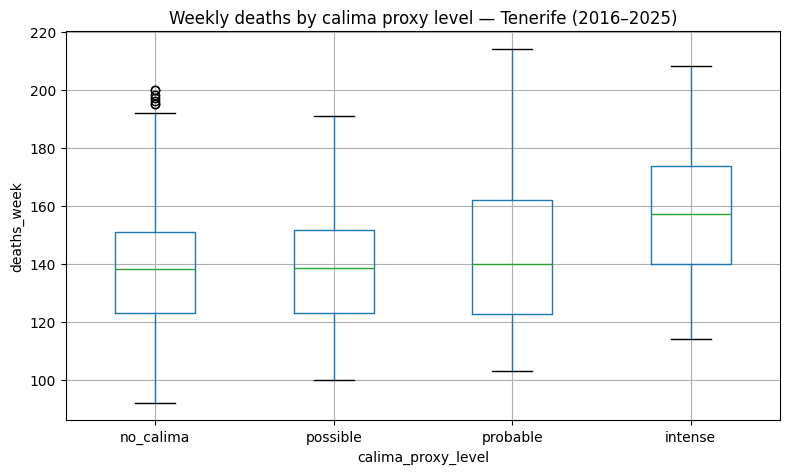

In [26]:
level_order = ["no_calima", "possible", "probable", "intense"]

plot_df = df.dropna(subset=["calima_proxy_level", "deaths_week"]).copy()
plot_df["calima_proxy_level"] = pd.Categorical(
    plot_df["calima_proxy_level"],
    categories=level_order,
    ordered=True
)
plot_df = plot_df.sort_values("calima_proxy_level")

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.boxplot(column="deaths_week", by="calima_proxy_level", ax=ax)

ax.set_title(f"Weekly deaths by calima proxy level — {ISLAND_NAME.capitalize()} (2016–2025)")
ax.set_xlabel("calima_proxy_level")
ax.set_ylabel("deaths_week")
plt.suptitle("")
plt.tight_layout()

autosave_fig(fig, FIG_DIR, f"deaths_by_calima_proxy_level_boxplot_{ISLAND_CODE}.png")
plt.show()

## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [27]:
tmp = df.copy()

if "calima_proxy_level" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(inter.reset_index(), TAB_DIR, "interaction_heat_p95_x_calima_intense_tfe.csv", index=False)


count        mean  median
heat_p95 calima_intense                           
0        0                 460  139.250000   138.0
         1                  36  157.500000   158.5
1        0                  23  137.391304   137.0
         1                   4  156.250000   153.5

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\interaction_heat_p95_x_calima_intense_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/interaction_heat_p95_x_calima_intense_tfe.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **-0.39**
- Δ deaths (calima intense vs baseline): **+18.72 deaths/week**
- Proxy coverage / missingness: **523/523 weeks covered, 0 missing (0.0%)**
- CAP yellow alignment with proxy: **69.5%**
- corr(deaths, tmax_c_mean): **-0.363**
- corr(deaths, Tmax anomaly): **0.054**